In [1]:
from cobaya import get_model

In [2]:
params = {'logA': 3.044,
 'n_s': 0.965,
 'h': 0.675,
 'omega_b': 0.02235,
 'omega_cdm': 0.120,
 'tau_reio': 0.0543,
         }

mode=get_model('class_lensingTT.yaml')
mode.logposterior(params)

[model] *WARNING* Ignored blocks/options: ['sampler', 'output']
[classy] `classy` module loaded successfully from /opt/anaconda3/envs/main/lib/python3.11/site-packages
ISWlensing: tt tp pp Nbins  98 98 98
ISWlensing: lmins  2 2 2
ISWlensing: lmaxs  99 99 99
ISWlensing: OK for resp calc
ISWlensing: Rfid test ok
ISWlensing: rebinning using inverse covariance weighting  83 7 2


LogPosterior(logpost=1.6477792502830968, logpriors=[2.7894037928589683], loglikes=array([-1.14162454]), derived=[2.0989031673191437e-09, 0.31384172488986367, 0.14299413590294416, 0.6860787971858595, 0.24529383108121505, 7.6847991943359375, 0.8112128943440539, 0.9873768914917629, 0.45445426777478926, 0.6071730905669276, 2.098903167319144, 1.8829033242359754, 13.785194922202777, 147.1192099219605], finite=False)

In [3]:
params = {'logA': 3.044,
 'ns': 0.965,
 'H0':67.5,
 'ombh2': 0.02235,
 'omch2': 0.120,
 'tau': 0.0543,
         }

mode=get_model('camb_lensingTT.yaml')
mode.logposterior(params)

[model] *WARNING* Ignored blocks/options: ['sampler', 'output']
[camb] *ERROR* Could not find CAMB: Could not import 'camb' (tried global import): No module named 'camb'. To install it, run `cobaya-install camb`


ComponentNotInstalledError: Could not find CAMB: Could not import 'camb' (tried global import): No module named 'camb'. To install it, run `cobaya-install camb`

In [ ]:
(1.1416-1.122)/1.122

In [4]:
import numpy as np
loaded_data = np.load('camb_cls.npz')
camb_cls = {key: loaded_data[key] for key in loaded_data.files}
loaded_data = np.load('class_cls.npz')
class_cls = {key: loaded_data[key] for key in loaded_data.files}

In [5]:
camb_cls['pt']-camb_cls['tp']

array([0., 0., 0., ..., 0., 0., 0.])

In [6]:
# class raw_cl---> lensed_cl
# camb lensed_cl

(0.99, 1.1)

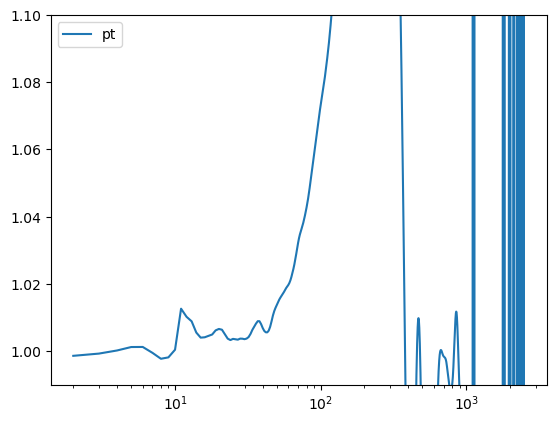

In [9]:
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
for k in class_cls.keys():
    if k=='ell': continue
    if k in ['tt','ee','pp','bb','te','tp']: continue
    iclass = interp1d(class_cls['ell'],class_cls[k])
    icamb = interp1d(camb_cls['ell'],camb_cls[k])
    ell = class_cls['ell'][2:]
    plt.plot(ell,iclass(ell)/icamb(ell),label=k)
plt.legend()
plt.semilogx()
plt.ylim(0.99,1.1)

(0.99, 1.1)

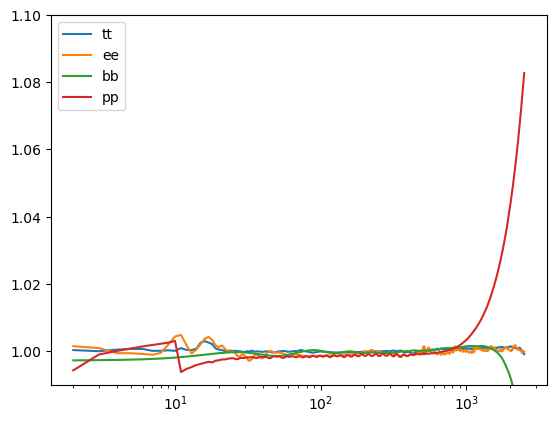

In [8]:
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
for k in class_cls.keys():
    if k=='ell': continue
    if k in ['pt','tp','te']: continue
    iclass = interp1d(class_cls['ell'],class_cls[k])
    icamb = interp1d(camb_cls['ell'],camb_cls[k])
    ell = class_cls['ell'][2:]
    plt.plot(ell,iclass(ell)/icamb(ell),label=k)
plt.legend()
plt.semilogx()
plt.ylim(0.99,1.1)